In [4]:
import psycopg2
from dotenv import load_dotenv
import os 

load_dotenv()
url = os.getenv("DATABASE_URL")

In [7]:
conn = psycopg2.connect(url, sslmode="require")
cur = conn.cursor()

In [8]:
cur.execute(
    """
    SELECT DISTINCT ticker
    FROM orderbooks
    """
)
tickers = [row[0] for row in cur.fetchall()]
print(tickers)

['SR320CC6', 'SR320CD6A', 'SR320CO6D', 'SR310CD6', 'SR300CD6A', 'SR310CC6D', 'SR300CP6', 'SR320CP6A', 'SR320CD6', 'SR300CO6D', 'SR320CP6', 'SR320CC6D', 'SR310CP6', 'SR300CD6', 'SR310CO6D', 'SR310CP6A', 'SR310CC6', 'SR300CC6D', 'SR300CP6A', 'SR300CC6', 'SR310CD6A']


In [9]:
import pandas as pd

ticker = "SR320CC6"
columns = ["id", "ticker", "timestamp", "bids", "asks"] 

query = f"""
SELECT {', '.join(columns)}
FROM orderbooks
WHERE ticker = '{ticker}'
"""

df = pd.read_sql_query(query, conn)

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

df['best_bid'] = df['bids'].apply(lambda bids: bids[0]['price'] if bids else None)
df['best_ask'] = df['asks'].apply(lambda asks: asks[0]['price'] if asks else None)
df['mid_price'] = df['best_bid'] + (df['best_ask'] - df['best_bid'])/2
df['spread'] = df['best_ask'] - df['best_bid']

df.drop(columns=['bids', 'asks', 'id'], inplace=True)
df = df[~df.index.duplicated(keep='first')]
df.drop_duplicates(inplace=True)
df.head()

C:\Users\bakae\AppData\Local\Temp\ipykernel_4688\2237263563.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,ticker,best_bid,best_ask,mid_price,spread
timestamp,,,,,
2026-03-11 16:44:09+00:00,SR320CC6,1.11,1.50,1.305,0.39
2026-03-12 07:27:03+00:00,SR320CC6,0.70,1.46,1.080,0.76
2026-03-12 07:27:06+00:00,SR320CC6,0.93,1.46,1.195,0.53
2026-03-11 16:50:00+00:00,SR320CC6,1.11,1.49,1.300,0.38
2026-03-11 17:12:59+00:00,SR320CC6,1.30,1.49,1.395,0.19


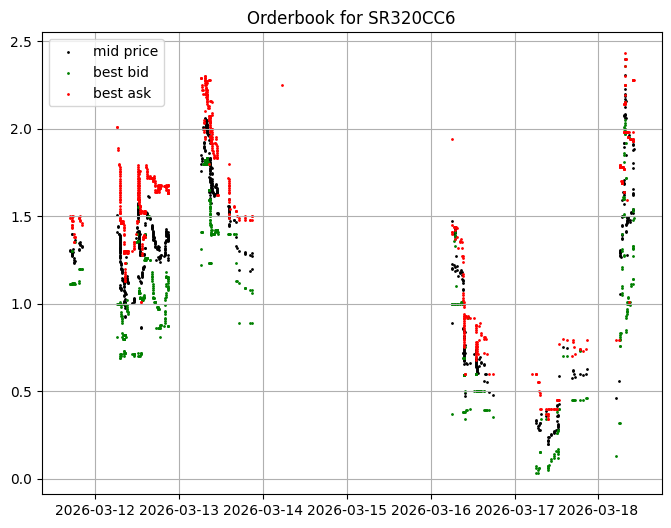

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df.index, df['mid_price'], color="black", s=1, label="mid price")
plt.scatter(df.index, df['best_bid'], color="green", s=1, label="best bid")
plt.scatter(df.index, df['best_ask'], color="red", s=1, label="best ask")
plt.title(f"Orderbook for {ticker}")
plt.legend()
plt.grid()
plt.show()